# AI-Powered Student Performance Prediction & Early Warning System

## Domain
Education

## Objective
To predict student academic performance using machine learning and identify students who are at risk of failing. The system also provides personalized study recommendations.

## Features
1. Student performance prediction
2. Early warning system (risk detection)
3. Personalized study recommendations

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import pickle

### Load Dataset

In [58]:
df = pd.read_csv("student_performance.csv")

### Dataset Information

In [59]:
df.head()

df.tail()

df.shape

df.columns

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           20 non-null     int64  
 1   StudentName         20 non-null     object 
 2   Class               20 non-null     int64  
 3   Attendance          20 non-null     int64  
 4   QuizScore           20 non-null     int64  
 5   AssignmentScore     20 non-null     int64  
 6   InternalExam        20 non-null     int64  
 7   PreviousPercentage  20 non-null     int64  
 8   Participation       20 non-null     int64  
 9   HomeworkCompletion  20 non-null     int64  
 10  BehaviourScore      20 non-null     int64  
 11  StudyHours          20 non-null     float64
 12  ParentMeeting       20 non-null     int64  
 13  FinalPercentage     20 non-null     int64  
 14  RiskLevel           20 non-null     object 
dtypes: float64(1), int64(12), object(2)
memory usage: 2.5+ KB


,StudentID,Class,Attendance,QuizScore,AssignmentScore,InternalExam,PreviousPercentage,Participation,HomeworkCompletion,BehaviourScore,StudyHours,ParentMeeting,FinalPercentage
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,1010.50000,10.250000,79.750000,71.950000,72.350000,70.400000,71.250000,2.250000,78.050000,3.750000,3.095000,0.600000,72.100000
std,5.91608,1.069924,14.067039,18.852544,19.214235,19.551282,16.864397,0.786398,18.126674,1.164158,1.381637,0.502625,18.730499
min,1001.00000,9.000000,54.000000,38.000000,35.000000,36.000000,41.000000,1.000000,45.000000,2.000000,1.000000,0.000000,39.000000
25%,1005.75000,9.000000,68.250000,56.500000,57.000000,53.750000,56.750000,2.000000,62.250000,3.000000,1.875000,0.000000,55.750000
50%,1010.50000,10.000000,83.500000,76.000000,76.500000,74.000000,73.000000,2.000000,82.000000,4.000000,3.050000,1.000000,76.000000
75%,1015.25000,11.000000,91.500000,88.500000,87.000000,88.250000,86.500000,3.000000,93.500000,5.000000,4.275000,1.000000,88.500000
max,1020.00000,12.000000,98.000000,97.000000,98.000000,96.000000,95.000000,3.000000,100.000000,5.000000,5.500000,1.000000,97.000000


### Check Missing Values

In [60]:
df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)

### Data Visualization

#### Attendance Distribution


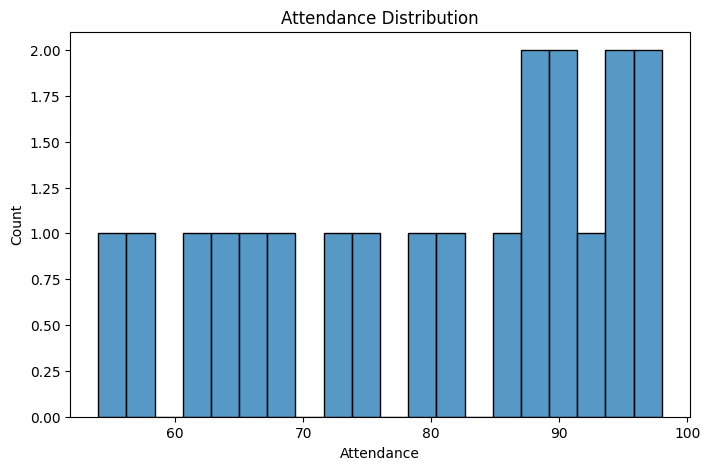

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df["Attendance"], bins=20)
plt.title("Attendance Distribution")
plt.show()

#### Risk Level Count

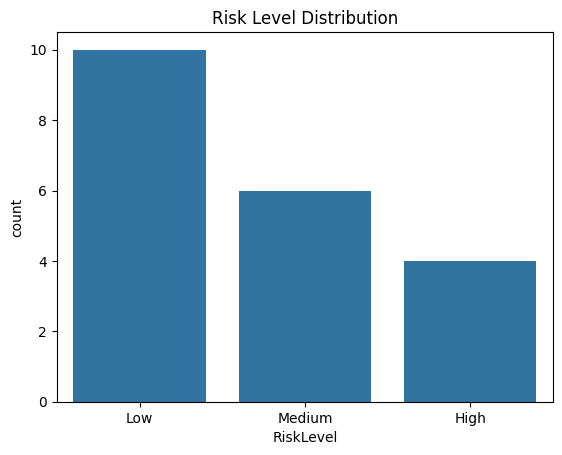

In [62]:
sns.countplot(
    x="RiskLevel",
    data=df
)

plt.title("Risk Level Distribution")
plt.show()

#### Correlation Heatmap

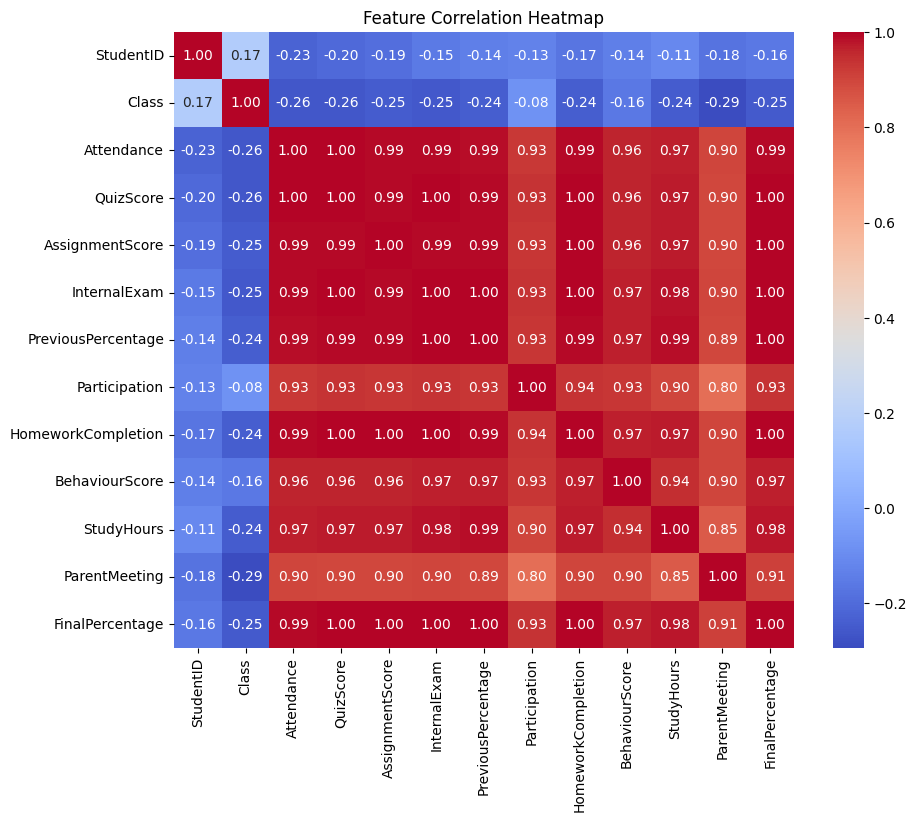

In [63]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

#### Attendance vs Final Percentage

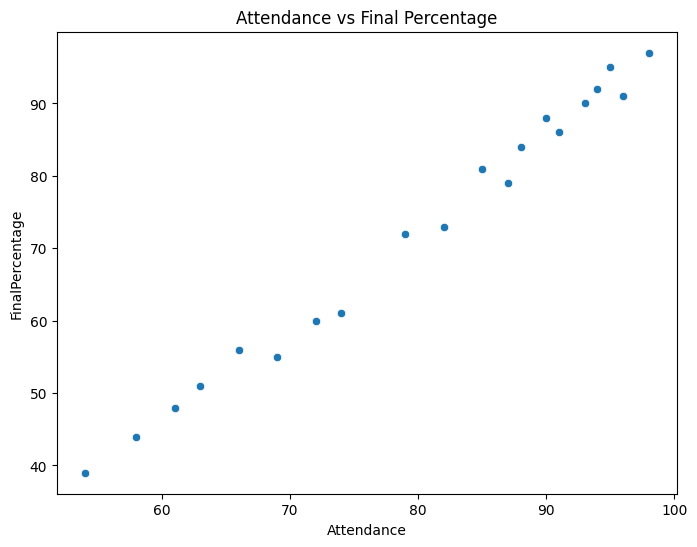

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Attendance",
    y="FinalPercentage",
    data=df
)

plt.title("Attendance vs Final Percentage")

plt.show()

#### Study Hours vs Final Percentage

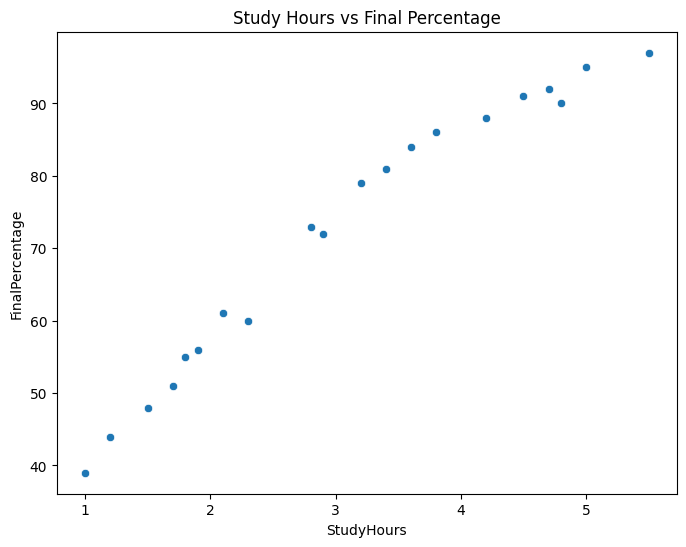

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="StudyHours",
    y="FinalPercentage",
    data=df
)

plt.title("Study Hours vs Final Percentage")

plt.show()

#### Box plot

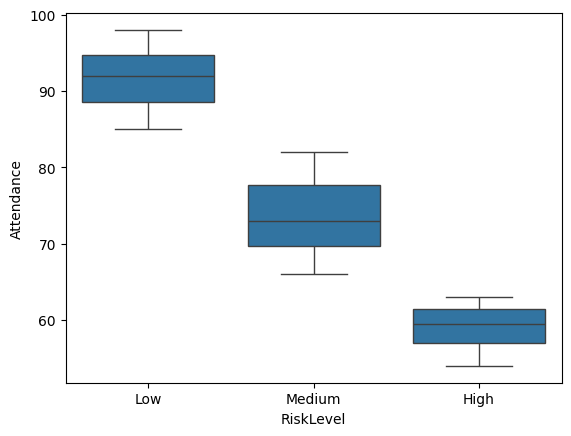

In [ ]:
sns.boxplot(
    x="RiskLevel",
    y="Attendance",
    data=df
)

plt.show()

### Feature Selection

In [67]:
features = [
    "Attendance",
    "QuizScore",
    "AssignmentScore",
    "InternalExam",
    "PreviousPercentage",
    "Participation",
    "HomeworkCompletion",
    "BehaviourScore",
    "StudyHours",
    "ParentMeeting"
]

X = df[features]

y = df["RiskLevel"]

### Train/Test Split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Train Machine Learning Model

In [69]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Predictions

In [70]:
predictions = model.predict(X_test)

### Model Evaluation

In [71]:
print("Accuracy")

print(
    accuracy_score(
        y_test,
        predictions
    )
)

Accuracy
1.0


#### Classification Report


In [ ]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         1
         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



#### Confusion Matrix

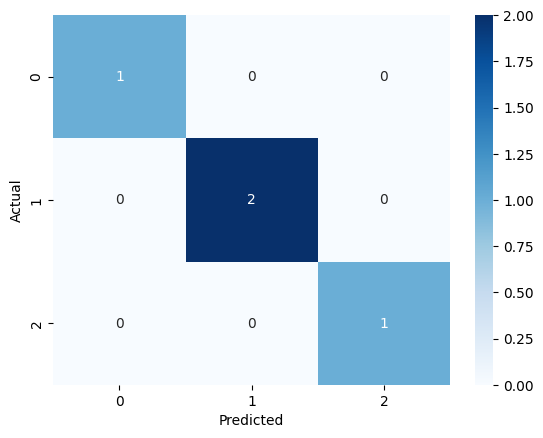

In [ ]:
cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Early Warning System (Risk Classification)

In [74]:
def early_warning(risk):

    if risk == "High":
        return "Immediate Teacher Intervention Required"

    elif risk == "Medium":
        return "Monitor Weekly"

    else:
        return "Student Performing Well"

### Recommendation System

In [75]:
def recommendation(row):

    recommendations = []

    if row["Attendance"] < 75:
        recommendations.append(
            "Improve attendance"
        )

    if row["QuizScore"] < 50:
        recommendations.append(
            "Attend remedial quiz sessions"
        )

    if row["AssignmentScore"] < 50:
        recommendations.append(
            "Complete pending assignments"
        )

    if row["Participation"] < 2:
        recommendations.append(
            "Participate more in classroom activities"
        )

    if row["StudyHours"] < 2:
        recommendations.append(
            "Increase daily study time"
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Keep up the excellent work"
        )

    return recommendations

### Test the System

In [76]:
new_student = pd.DataFrame({

    "Attendance":[62],
    "QuizScore":[41],
    "AssignmentScore":[55],
    "InternalExam":[48],
    "PreviousPercentage":[58],
    "Participation":[1],
    "HomeworkCompletion":[60],
    "BehaviourScore":[3],
    "StudyHours":[1.5],
    "ParentMeeting":[0]

})

#### Predict

In [ ]:
prediction = model.predict(
    new_student
)

print(prediction)

['High']


#### Generate Warning

In [ ]:
print(
    early_warning(
        prediction[0]
    )
)

Immediate Teacher Intervention Required


#### Generate Recommendations


In [ ]:
print(
    recommendation(
        new_student.iloc[0]
    )
)

['Improve attendance', 'Attend remedial quiz sessions', 'Participate more in classroom activities', 'Increase daily study time']


### Feature Importance

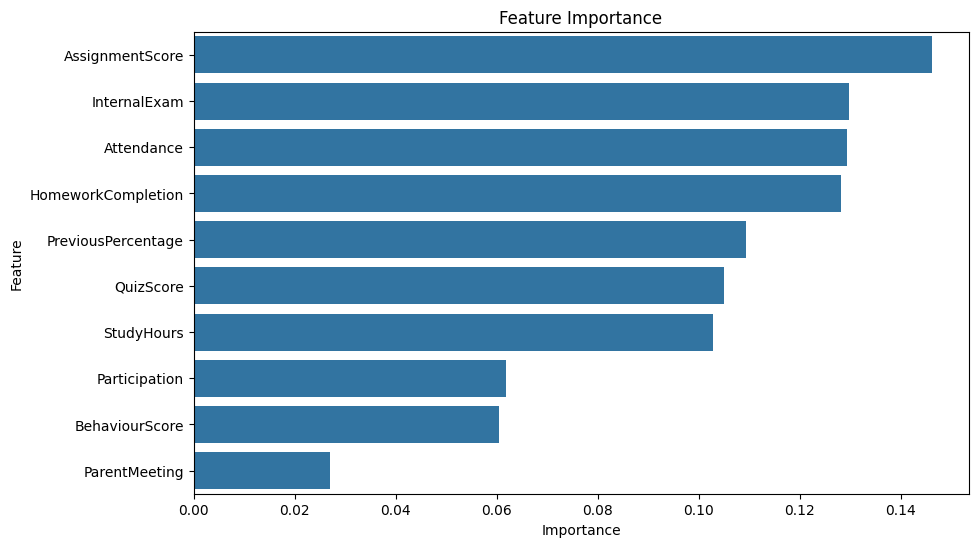

In [80]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

### Save the model

In [ ]:
with open(
    "student_model.pkl",
    "wb"
) as file:

    pickle.dump(
        model,
        file
    )

# Conclusion

This project demonstrates how Machine Learning can help teachers identify students who are at academic risk before final examinations. Using factors such as attendance, quiz scores, assignments, study hours, and previous performance, the system predicts a student's risk level (Low, Medium, or High) and provides personalized recommendations for early intervention.

The project shows how AI can support better decision-making in education and help improve student performance through timely guidance.

In [83]:
import os
import pickle

# Create model folder if it does not exist
os.makedirs("model", exist_ok=True)

# Save the trained classifier
with open("model/student_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("✅ Model saved successfully!")
print("📁 Location : model/student_model.pkl")

✅ Model saved successfully!
📁 Location : model/student_model.pkl


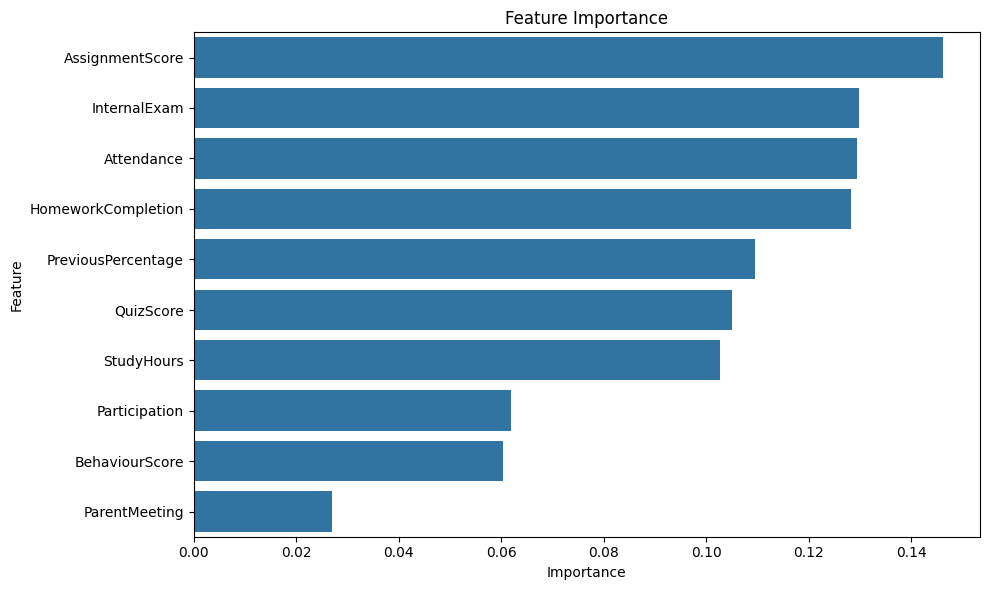

In [85]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig("screenshots/feature_importance.png")

plt.show()